[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\subbu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\subbu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Tokens:
 ['artificial', 'intelligence', 'is', 'transforming', 'healthcare', 'and', 'education', 'systems', 'ai', 'and', 'machine', 'learning', 'are', 'the', 'future', 'of', 'technology', 'and', 'innovation', 'healthcare', 'systems', 'are', 'improving', 'with', 'artificial', 'intelligence', 'solutions', 'education', 'technology', 'is', 'growing', 'rapidly', 'with', 'ai', 'based', 'tools']

Filtered words:
 ['artificial', 'intelligence', 'transforming', 'healthcare', 'education', 'systems', 'ai', 'machine', 'learning', 'future', 'technology', 'innovation', 'healthcare', 'systems', 'improving', 'artificial', 'intelligence', 'solutions', 'education', 'technology', 'growing', 'rapidly', 'ai', 'based', 'tools']

Word Frequencies:
 Counter({'artificial': 2, 'intelligence': 2, 'healthcare': 2, 'education': 2, 'systems': 2, 'ai': 2, 'technology': 2, 'transforming': 1, 'machine': 1, 'learning': 1, 'future': 1, 'innovation': 1, 'improving': 1, 'solutions': 1, 'growing': 1, 'rapidly': 1, 'based': 

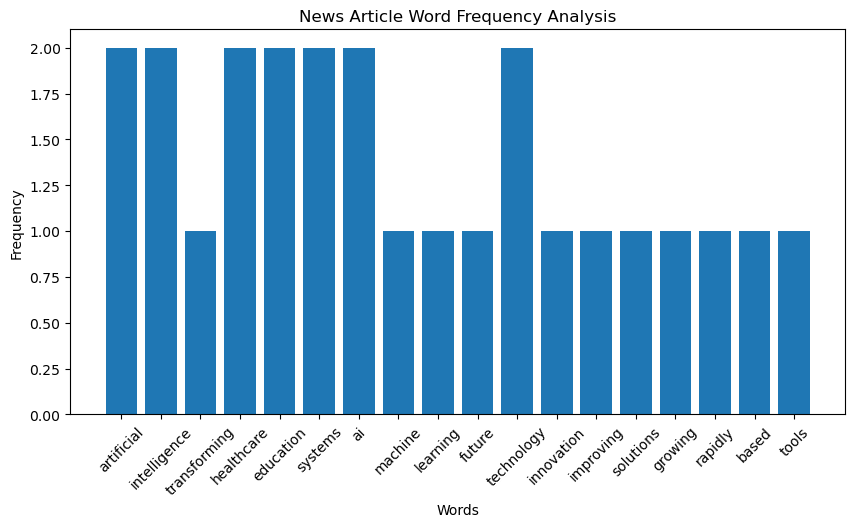

In [2]:
from collections import Counter
import nltk
import string
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

#sample news
text = """
Artificial intelligence is transforming healthcare and education systems.
AI and machine learning are the future of technology and innovation.
Healthcare systems are improving with artificial intelligence solutions.
Education technology is growing rapidly with AI based tools.
"""

#step 1: convert to lowercase
text = text.lower()

#step 2: remove punctuation
for t in string.punctuation:
    text = text.replace(t,"")

#step 3: tokenization
words = word_tokenize(text)
print("Tokens:\n",words)

#step 4:remove stopwords
stop_words = set(stopwords.words("english"))
filtered_words = [w for w in words if w not in stop_words]
print("\nFiltered words:\n",filtered_words)

#step 5: compute word frequency distribution
freq = Counter(filtered_words)
print("\nWord Frequencies:\n",freq)

#step 6: build vocabulary
vocabulary = set(filtered_words)
print("\nVocabulary:")
print(vocabulary)
print("Vocabulary Size =",len(vocabulary))

#step 7: top 5 most frequent words
print("\nTop 5 Most Frequent Words:")
for word,count in freq.most_common(5):
    print(word, ":" ,count)

#step 8: type token ratio
total_tokens = len(filtered_words)
ttr = len(vocabulary)/total_tokens
print("\nType Token Ratio(TTR) =",round(ttr,2))

#step 9: identify dominant topic 
topics = {
    "Artificial Intelligence": ["ai", "artificial", "intelligence", "machine", "learning"],
    "Healthcare": ["healthcare", "systems", "solutions"],
    "Education": ["education", "tools"],
    "Technology": ["technology", "innovation"]
}

topic_scores = {}

for topic,keywords in topics.items():
    score = 0
    for word in keywords:
        score += freq[word]
    topic_scores[topic] = score

print("\nTopic Scores:")
for topic,score in topic_scores.items():
    print(topic, ":", score)

dominant_topic = max(topic_scores, key=topic_scores.get)
print("\nMost Dominant Topic =",dominant_topic)

#step 10: visualization
word_list = list(freq.keys())
count_list = list(freq.values())

plt.figure(figsize=(10,5))
plt.bar(word_list,count_list)
plt.title("News Article Word Frequency Analysis")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()
